# QQQ 매수 방식별 인출 백테스트

투자 조건을 입력하고 아래 코드 셀을 실행하세요. 일시매수, 균등 분할매수, 추세추종 매수의 시작연도별 10년 후 결과를 비교합니다.


## 실행 조건
- 투자종목: **QQQ**
- 시작연도: **2002~2016년**
- 투자기간: **10년**
- 초기 준비금: **1억원**
- 월 인출액: **100만원**
- 분할매수기간: **18개월**

## 시작연도별 생존 결과

시작연도,일시매수,균등 분할매수,추세추종 매수
2002,✕ 6년 5개월,✓ 10년 유지,✓ 10년 유지
2003,✓ 10년 유지,✓ 10년 유지,✓ 10년 유지
2004,✕ 9년 6개월,✓ 10년 유지,✕ 9년 6개월
2005,✓ 10년 유지,✓ 10년 유지,✓ 10년 유지
2006,✓ 10년 유지,✓ 10년 유지,✓ 10년 유지
2007,✓ 10년 유지,✓ 10년 유지,✓ 10년 유지
2008,✓ 10년 유지,✓ 10년 유지,✓ 10년 유지
2009,✓ 10년 유지,✓ 10년 유지,✓ 10년 유지
2010,✓ 10년 유지,✓ 10년 유지,✓ 10년 유지
2011,✓ 10년 유지,✓ 10년 유지,✓ 10년 유지


## 매수 방식별 최종 잔액

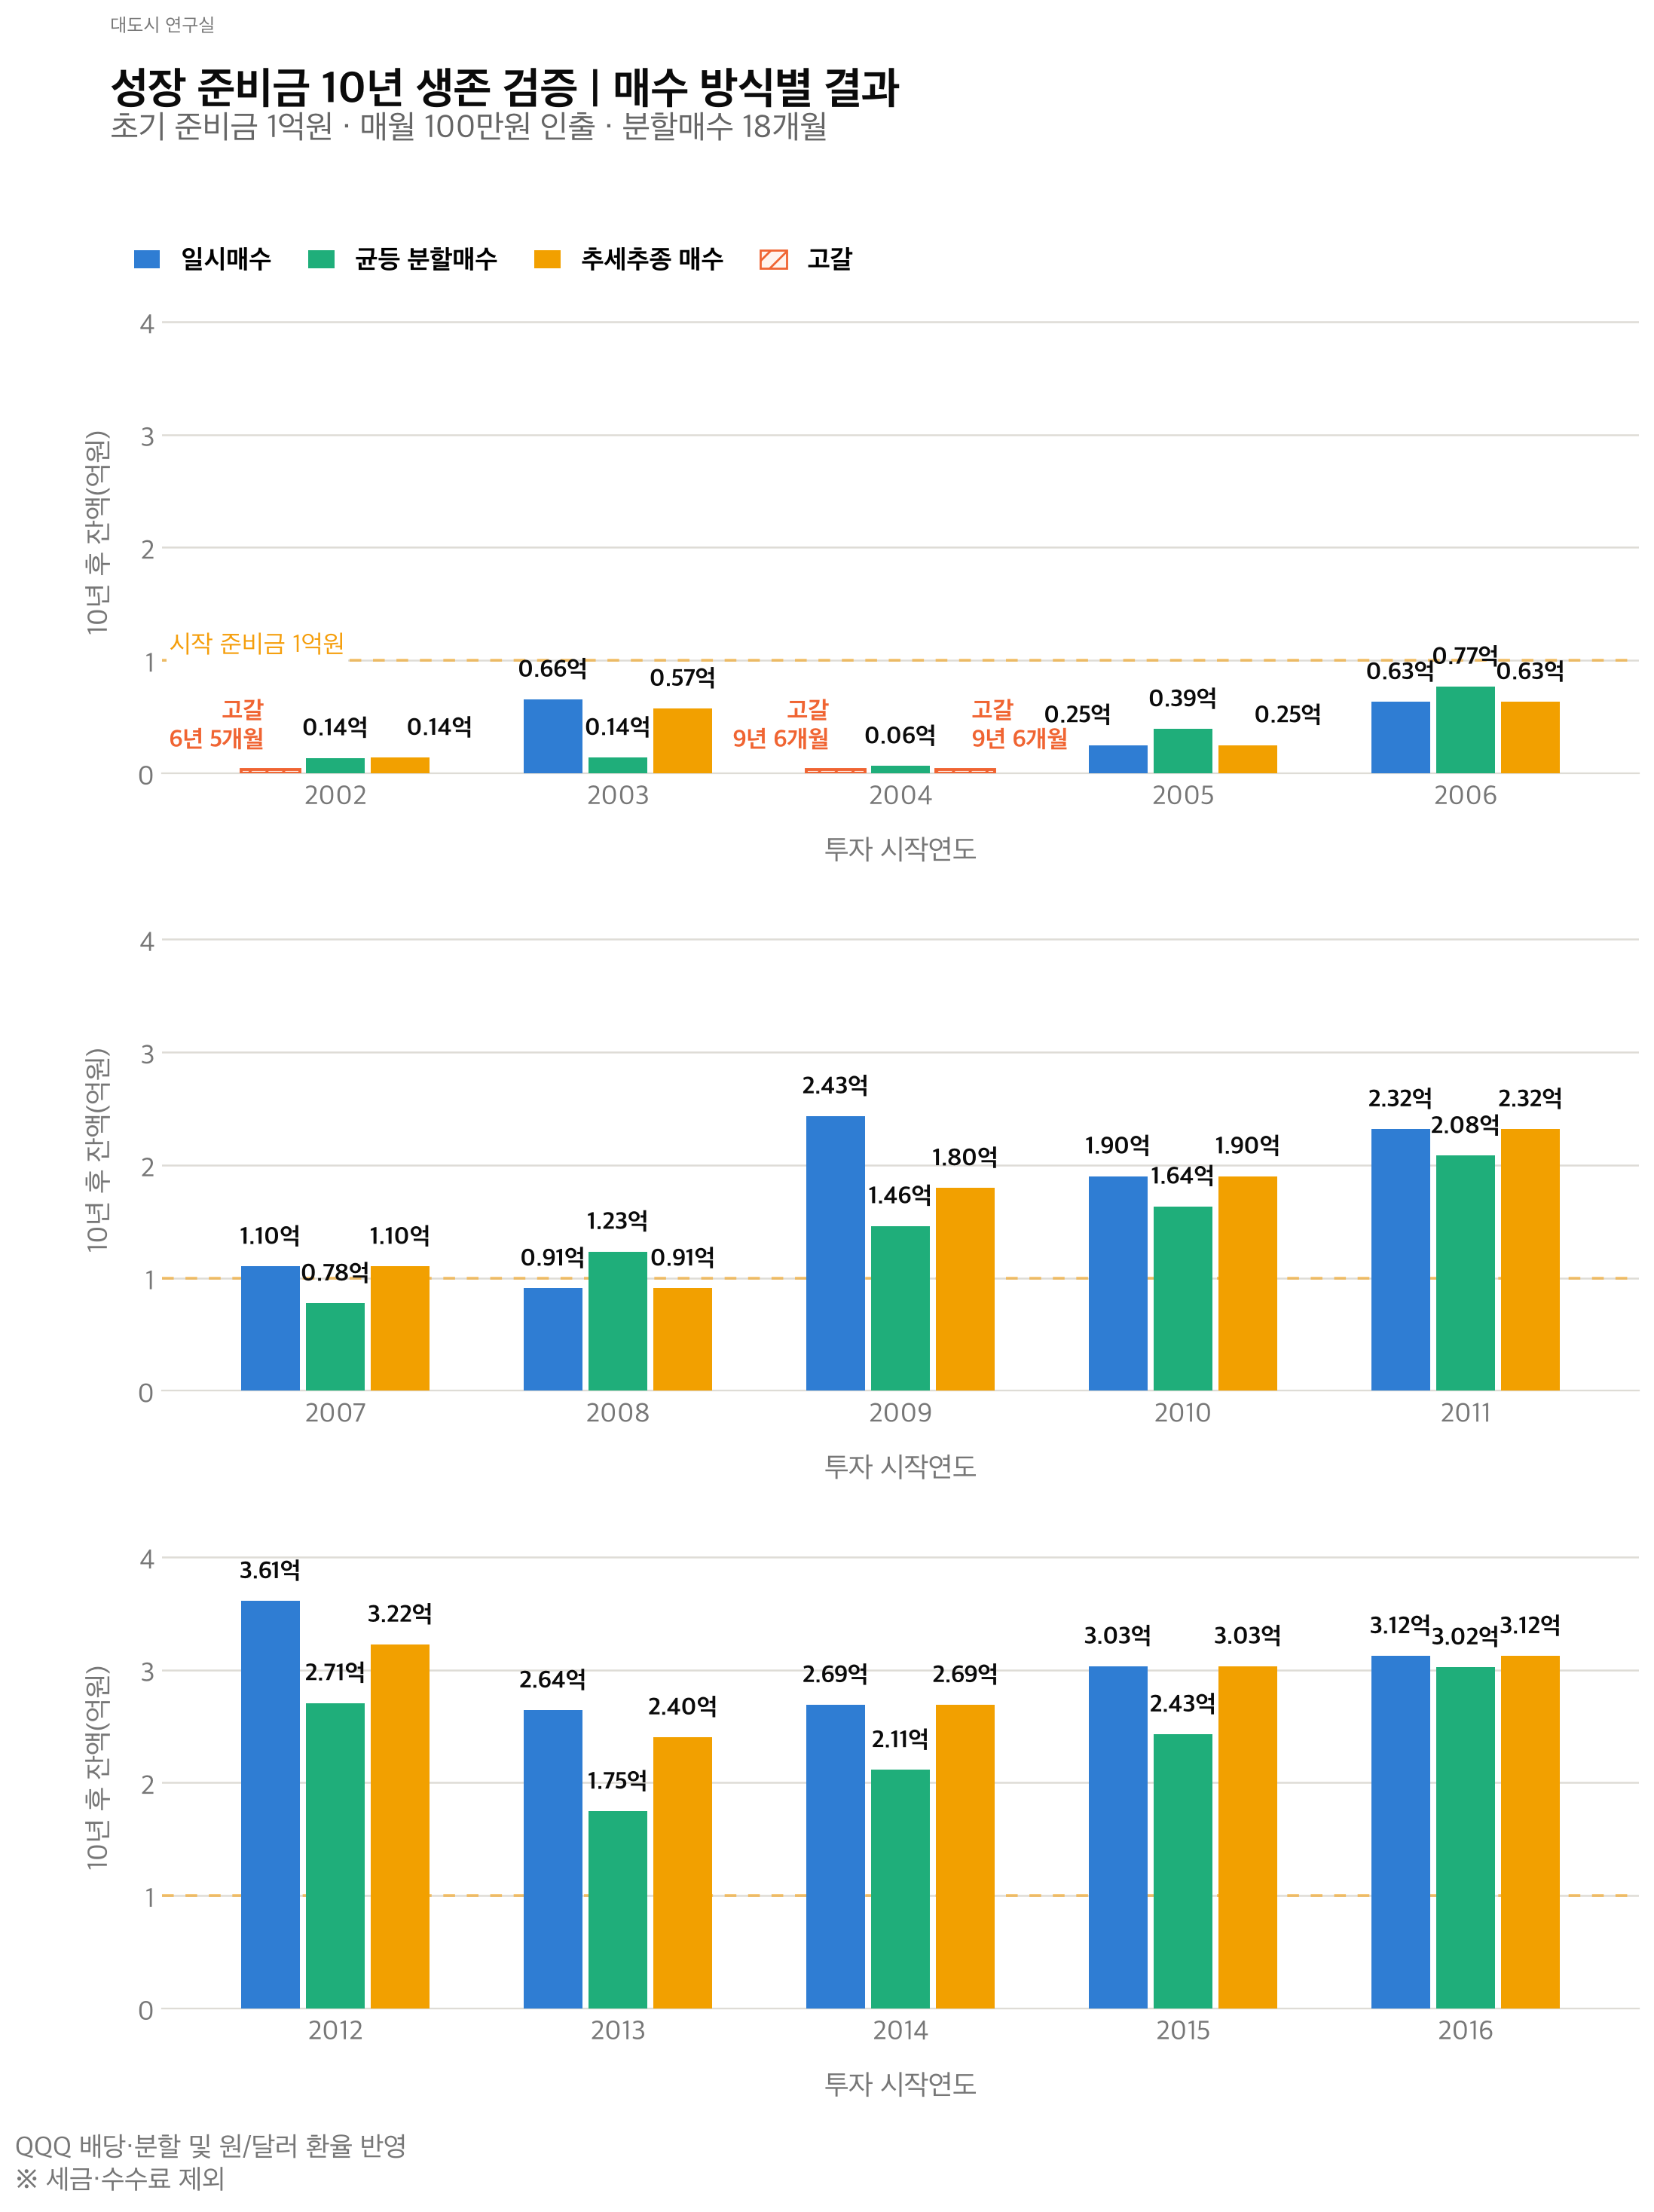

## 결과 파일 다운로드

/Users/1111429/src/daedosee-lab/qqq_purchase_strategy_backtest/output/qqq_10y_purchase_strategy_summary.csv

/Users/1111429/src/daedosee-lab/qqq_purchase_strategy_backtest/output/qqq_10y_purchase_strategy_monthly_detail.csv

/Users/1111429/src/daedosee-lab/qqq_purchase_strategy_backtest/output/qqq_10y_purchase_strategy_ending_balance.png

In [ ]:
# @title 백테스트 조건을 입력하고 실행하세요
투자종목 = "QQQ"  # @param {type:"string"}
최초_시작연도 = 2002  # @param {type:"integer"}
마지막_시작연도 = 2016  # @param {type:"integer"}
투자기간_년 = 10  # @param {type:"integer", min:1, step:1}
초기준비금_억원 = 1.0  # @param {type:"number", min:0.01, step:0.1}
월인출액_만원 = 100  # @param {type:"number", min:0, step:10}
분할매수기간_개월 = 12  # @param {type:"integer", min:1, step:1}

"""미국 ETF의 매수 방식별 정기 인출 결과를 비교한다.

선택 종목 가격은 Yahoo Finance 월봉 데이터(배당·주식분할 반영),
원/달러 환율은 미국 연준 FRED DEXKOUS를 사용한다. 세금,
환전·거래 수수료와 물가상승률은 반영하지 않는다.

미투자 준비금은 이자가 없는 원화 현금으로 보유한다. 매월 말 현금에서 먼저
인출하고, 부족하면 보유 종목을 매도한다. 추세추종은 월봉 종가가 10개월
이동평균을 상회하면 같은 월말 가격으로 남은 준비금을 모두 투자한다.
"""

import math
import os
from pathlib import Path
import subprocess
import sys
from typing import Any, cast
from urllib.request import urlretrieve

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import font_manager
from matplotlib.axes import Axes
from matplotlib.patches import Patch
import pandas as pd


def is_colab_runtime() -> bool:
    """현재 코드가 Google Colab에서 실행 중인지 확인한다."""
    return bool(os.environ.get("COLAB_RELEASE_TAG")) or Path("/content").exists()


IS_COLAB = is_colab_runtime()
OUTPUT_DIR = Path("/content/output") if IS_COLAB else Path("output")

WON_PER_EOK = 100_000_000
WON_PER_MANWON = 10_000
MONTHS_PER_YEAR = 12
MOVING_AVERAGE_MONTHS = 10
MIN_START_YEAR = 2000

TICKER = str(투자종목).strip().upper()
FIRST_START_YEAR = int(최초_시작연도)
LAST_START_YEAR = int(마지막_시작연도)
INVESTMENT_YEARS = int(투자기간_년)
INITIAL_RESERVE_KRW = float(초기준비금_억원) * WON_PER_EOK
MONTHLY_WITHDRAWAL_KRW = float(월인출액_만원) * WON_PER_MANWON
INSTALLMENT_MONTHS = int(분할매수기간_개월)
TOTAL_MONTHS = INVESTMENT_YEARS * MONTHS_PER_YEAR

METHODS = (
    ("lump_sum", "일시매수"),
    ("equal_installment", "균등 분할매수"),
    ("trend_following", "추세추종 매수"),
)
METHOD_LABELS = dict(METHODS)

try:
    import yfinance as yf
except ImportError:
    if IS_COLAB:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "yfinance"]
        )
        import yfinance as yf
    else:
        raise


# =============================================================================
# 1. 입력 검증과 시장 데이터
# =============================================================================


def validate_parameters() -> None:
    """Colab 입력값을 검증한다."""
    if not TICKER:
        raise ValueError("투자종목을 입력하세요.")
    if FIRST_START_YEAR > LAST_START_YEAR:
        raise ValueError("최초 시작연도는 마지막 시작연도보다 늦을 수 없습니다.")
    if FIRST_START_YEAR < MIN_START_YEAR:
        raise ValueError(f"시작연도는 {MIN_START_YEAR}년 이후로 입력하세요.")
    if INVESTMENT_YEARS <= 0 or INITIAL_RESERVE_KRW <= 0:
        raise ValueError("투자기간과 초기 준비금은 0보다 커야 합니다.")
    if MONTHLY_WITHDRAWAL_KRW < 0:
        raise ValueError("월 인출액은 0 이상이어야 합니다.")
    if INSTALLMENT_MONTHS <= 0:
        raise ValueError("분할매수기간은 1개월 이상이어야 합니다.")


def download_monthly_prices() -> pd.Series:
    """이동평균 계산 기간을 포함한 월말 가격을 내려받는다."""
    first_trade_month = pd.Timestamp(FIRST_START_YEAR - 1, 12, 31)
    lookback_month = first_trade_month - pd.offsets.MonthEnd(
        MOVING_AVERAGE_MONTHS - 1
    )
    start = lookback_month.replace(day=1).strftime("%Y-%m-%d")
    end = f"{LAST_START_YEAR + INVESTMENT_YEARS + 1}-01-01"
    raw = yf.download(
        TICKER,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        actions=False,
    )
    if raw is None or raw.empty:
        raise RuntimeError(f"{TICKER} 가격 데이터를 내려받지 못했습니다.")

    adjusted_close = raw["Adj Close"]
    if isinstance(adjusted_close, pd.DataFrame):
        frame = cast(pd.DataFrame, adjusted_close)
        adjusted_close = (
            frame[TICKER] if TICKER in frame.columns else frame.iloc[:, 0]
        )
    monthly = adjusted_close.dropna().astype(float).resample("ME").last()
    monthly.name = "adjusted_close"
    return monthly


def download_monthly_usdkrw() -> pd.Series:
    """투자 기간의 월말 원/달러 환율을 FRED에서 내려받는다."""
    start = f"{FIRST_START_YEAR - 1}-12-01"
    end = f"{LAST_START_YEAR + INVESTMENT_YEARS}-12-31"
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv"
        f"?id=DEXKOUS&cosd={start}&coed={end}"
    )
    raw = pd.read_csv(url)
    date_column = "observation_date" if "observation_date" in raw else "DATE"
    raw[date_column] = pd.to_datetime(raw[date_column])
    values = pd.to_numeric(raw["DEXKOUS"], errors="coerce")
    daily = pd.Series(
        values.to_numpy(), index=raw[date_column], name="usdkrw"
    ).dropna()
    return daily.resample("ME").last()


def load_market_data() -> pd.DataFrame:
    """월말 가격, 이동평균과 환율을 하나의 데이터로 준비한다."""
    prices = download_monthly_prices()
    moving_average = prices.rolling(MOVING_AVERAGE_MONTHS).mean().rename("ma10")
    fx_rates = download_monthly_usdkrw()
    return pd.concat([prices, moving_average, fx_rates], axis=1)


def market_for_start(market: pd.DataFrame, start_year: int) -> pd.DataFrame:
    """한 시작연도의 최초 매수월부터 투자 종료월까지 데이터를 검증한다."""
    first_month = pd.Timestamp(start_year, 1, 31)
    trade_month = first_month - pd.offsets.MonthEnd(1)
    final_month = first_month + pd.offsets.MonthEnd(TOTAL_MONTHS - 1)
    required = market.loc[trade_month:final_month].copy()
    expected_count = TOTAL_MONTHS + 1
    if len(required) != expected_count or required.isna().any().any():
        raise RuntimeError(
            f"{start_year}년 시장 데이터가 부족하거나 월말 인덱스가 "
            f"일치하지 않습니다({expected_count}개월 필요)."
        )
    return required


# =============================================================================
# 2. 매수·인출 백테스트
# =============================================================================


def buy_with_cash(
    cash_krw: float,
    shares: float,
    requested_krw: float,
    price_usd: float,
    fx_rate: float,
) -> tuple[float, float, float]:
    """요청액과 보유 현금 중 작은 금액으로 종목을 매수한다."""
    purchase_krw = min(max(requested_krw, 0.0), cash_krw)
    purchased_shares = purchase_krw / (price_usd * fx_rate)
    return cash_krw - purchase_krw, shares + purchased_shares, purchase_krw


def withdraw_from_portfolio(
    cash_krw: float,
    shares: float,
    requested_krw: float,
    price_usd: float,
    fx_rate: float,
) -> tuple[float, float, float, float]:
    """현금에서 먼저 인출하고 부족한 금액만큼 종목을 매도한다."""
    cash_withdrawal = min(cash_krw, requested_krw)
    cash_krw -= cash_withdrawal
    remaining = requested_krw - cash_withdrawal

    share_value_krw = shares * price_usd * fx_rate
    sale_krw = min(remaining, share_value_krw)
    sold_shares = sale_krw / (price_usd * fx_rate)
    shares = max(shares - sold_shares, 0.0)
    return cash_krw, shares, cash_withdrawal + sale_krw, sold_shares


def purchase_request(
    method: str,
    cash_krw: float,
    installment_count: int,
    base_installment_krw: float,
    price_usd: float,
    moving_average: float,
) -> tuple[float, str]:
    """매수 방식과 월말 추세에 따라 이번 달 매수 요청액을 정한다."""
    if method == "lump_sum":
        return cash_krw, "전액매수"
    if method == "equal_installment":
        if installment_count < INSTALLMENT_MONTHS:
            return base_installment_krw, "균등분할"
        return 0.0, "매수완료"
    if price_usd > moving_average:
        return cash_krw, "이동평균 상회·전액매수"
    if installment_count < INSTALLMENT_MONTHS:
        return base_installment_krw, "이동평균 이하·분할매수"
    return 0.0, "매수완료"


def simulate_strategy(
    market: pd.DataFrame,
    start_year: int,
    method: str,
) -> tuple[dict[str, Any], pd.DataFrame]:
    """한 시작연도와 매수 방식의 월별 인출 과정을 계산한다."""
    required = market_for_start(market, start_year)
    cash_krw = float(INITIAL_RESERVE_KRW)
    shares = 0.0
    installment_count = 0
    base_installment_krw = INITIAL_RESERVE_KRW / INSTALLMENT_MONTHS
    total_withdrawn_krw = 0.0
    total_purchased_krw = 0.0
    depletion_date = None
    rows: list[dict[str, Any]] = []

    for month_number, (date, values) in enumerate(required.iterrows()):
        price_usd = float(values["adjusted_close"])
        moving_average = float(values["ma10"])
        fx_rate = float(values["usdkrw"])
        cash_before = cash_krw
        shares_before = shares

        if month_number == 0:
            actual_withdrawal_krw = 0.0
            sold_shares = 0.0
        else:
            cash_krw, shares, actual_withdrawal_krw, sold_shares = (
                withdraw_from_portfolio(
                    cash_krw,
                    shares,
                    MONTHLY_WITHDRAWAL_KRW,
                    price_usd,
                    fx_rate,
                )
            )
            total_withdrawn_krw += actual_withdrawal_krw
            remaining_balance_krw = cash_krw + shares * price_usd * fx_rate
            if (
                actual_withdrawal_krw + 0.5 < MONTHLY_WITHDRAWAL_KRW
                or remaining_balance_krw <= 0.5
            ):
                depletion_date = date

        purchase_krw = 0.0
        signal = "고갈"
        if depletion_date is None:
            requested_purchase_krw, signal = purchase_request(
                method,
                cash_krw,
                installment_count,
                base_installment_krw,
                price_usd,
                moving_average,
            )
            cash_krw, shares, purchase_krw = buy_with_cash(
                cash_krw,
                shares,
                requested_purchase_krw,
                price_usd,
                fx_rate,
            )
            if method != "lump_sum" and purchase_krw > 0:
                installment_count += 1
            total_purchased_krw += purchase_krw

        equity_krw = shares * price_usd * fx_rate
        ending_balance_krw = cash_krw + equity_krw
        rows.append(
            {
                "start_year": start_year,
                "method": method,
                "method_label": METHOD_LABELS[method],
                "month_number": month_number,
                "date": date,
                "adjusted_close_usd": price_usd,
                "moving_average_10m_usd": moving_average,
                "usdkrw": fx_rate,
                "signal": signal,
                "cash_before_krw": cash_before,
                "shares_before": shares_before,
                "requested_withdrawal_krw": (
                    0.0 if month_number == 0 else MONTHLY_WITHDRAWAL_KRW
                ),
                "actual_withdrawal_krw": actual_withdrawal_krw,
                "sold_shares": sold_shares,
                "purchase_krw": purchase_krw,
                "ending_cash_krw": cash_krw,
                "ending_shares": shares,
                "ending_equity_krw": equity_krw,
                "ending_balance_krw": ending_balance_krw,
            }
        )
        if depletion_date is not None:
            break

    months_survived = max(len(rows) - 1, 0)
    last_row = rows[-1]
    summary = {
        "start_year": start_year,
        "method": method,
        "method_label": METHOD_LABELS[method],
        "depleted_within_period": depletion_date is not None,
        "depletion_month": (
            depletion_date.strftime("%Y-%m") if depletion_date is not None else "-"
        ),
        "months_survived": months_survived,
        "total_withdrawn_krw": total_withdrawn_krw,
        "total_purchased_krw": total_purchased_krw,
        "ending_cash_krw": last_row["ending_cash_krw"],
        "ending_equity_krw": last_row["ending_equity_krw"],
        "ending_balance_krw": last_row["ending_balance_krw"],
    }
    return summary, pd.DataFrame(rows)


def calculate_results(market: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """모든 시작연도와 매수 방식의 요약 및 월별 결과를 계산한다."""
    summaries: list[dict[str, Any]] = []
    details: list[pd.DataFrame] = []
    for start_year in range(FIRST_START_YEAR, LAST_START_YEAR + 1):
        for method, _ in METHODS:
            summary, detail = simulate_strategy(market, start_year, method)
            summaries.append(summary)
            details.append(detail)
    return pd.DataFrame(summaries), pd.concat(details, ignore_index=True)


# =============================================================================
# 3. 숫자와 화면 표시
# =============================================================================


def format_duration(months: int) -> str:
    """개월 수를 읽기 쉬운 연·개월 문자열로 변환한다."""
    years, remaining_months = divmod(months, MONTHS_PER_YEAR)
    if remaining_months == 0:
        return f"{years}년"
    if years == 0:
        return f"{remaining_months}개월"
    return f"{years}년 {remaining_months}개월"


def format_korean_won(amount: float) -> str:
    """원화 금액을 억원·만원 단위로 표시한다."""
    rounded_manwon = int(amount / WON_PER_MANWON + 0.5)
    if rounded_manwon == 0:
        return "0원"
    eok, manwon = divmod(rounded_manwon, WON_PER_EOK // WON_PER_MANWON)
    if eok and manwon:
        return f"{eok:,}억 {manwon:,}만원"
    if eok:
        return f"{eok:,}억원"
    return f"{manwon:,}만원"


def evaluated_final_balance(result: Any) -> float:
    """고갈 시 미충족 인출액을 음수로 반영한 최종 잔액을 반환한다."""
    if bool(result.depleted_within_period):
        planned_withdrawal = TOTAL_MONTHS * MONTHLY_WITHDRAWAL_KRW
        return -(planned_withdrawal - float(result.total_withdrawn_krw))
    return float(result.ending_balance_krw)


def average_final_balances(summary: pd.DataFrame) -> dict[str, float]:
    """매수 방식별 평가 최종 잔액의 시작연도 평균을 계산한다."""
    averages = {}
    for method, _ in METHODS:
        method_rows = summary.loc[summary["method"] == method]
        values = [
            evaluated_final_balance(cast(Any, row))
            for row in method_rows.itertuples(index=False)
        ]
        averages[method] = sum(values) / len(values)
    return averages


def result_table_html(summary: pd.DataFrame) -> str:
    """10년 후 잔액 또는 미충족 인출액과 요약 통계를 표로 만든다."""
    def format_result_value(value: float) -> str:
        formatted = format_korean_won(abs(value))
        return f"-{formatted}" if value < 0 else formatted

    rows: list[dict[str, Any]] = []
    survival_by_method = {method: 0 for method, _ in METHODS}
    for start_year in sorted(summary["start_year"].unique()):
        row: dict[str, Any] = {"시작연도": int(start_year)}
        year_rows = summary.loc[summary["start_year"] == start_year]
        for method, label in METHODS:
            result = cast(Any, year_rows.loc[year_rows["method"] == method].iloc[0])
            depleted = bool(result.depleted_within_period)
            value = evaluated_final_balance(result)
            survival_by_method[method] += int(not depleted)
            row[label] = (
                f'<span class="depleted-value">'
                f"-{format_korean_won(abs(value))} "
                f"({format_duration(int(result.months_survived))} 후 고갈)</span>"
                if depleted
                else format_korean_won(value)
            )
        rows.append(row)

    case_count = len(summary["start_year"].unique())
    average_row: dict[str, Any] = {"시작연도": "평균 최종 잔액"}
    average_balances = average_final_balances(summary)
    lump_sum_average = average_balances["lump_sum"]
    for method, label in METHODS:
        average = average_balances[method]
        relative_ratio = average / lump_sum_average if lump_sum_average else math.nan
        ratio_text = f"{relative_ratio:.1%}" if math.isfinite(relative_ratio) else "-"
        average_row[label] = f"{format_result_value(average)} ({ratio_text})"
    rows.append(average_row)

    survival_row: dict[str, Any] = {"시작연도": "생존율"}
    for method, label in METHODS:
        survived = survival_by_method[method]
        survival_row[label] = (
            f"{survived}/{case_count} ({survived / case_count:.1%})"
        )
    rows.append(survival_row)

    table = pd.DataFrame(rows).to_html(
        index=False, border=0, classes="result-table", escape=False
    )
    css = """
    <style>
    .result-table-wrap {max-width:700px; margin:12px 0 28px; overflow-x:auto;
      border:1px solid #f0f2f5; border-radius:12px;}
    .result-table {width:100%; border-collapse:separate; border-spacing:0;
      font-family:Pretendard,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;
      font-size:13px; font-variant-numeric:tabular-nums; color:#1e293b;}
    .result-table thead th {padding:8px 12px; background:#2b4a75;
      border-bottom:2px solid #7fb3d5; color:white; font-weight:700;
      text-align:center; white-space:nowrap;}
    .result-table tbody td {padding:7px 12px; border-bottom:1px solid #f0f2f5;
      background:white; text-align:center; white-space:nowrap;}
    .result-table tbody td:first-child {font-weight:600;}
    .result-table tbody tr:nth-child(even) td {background:#fafbfc;}
    .result-table tbody tr:nth-last-child(-n+2) td {font-weight:700;
      background:#f5f8fc;}
    .result-table tbody tr:nth-last-child(2) td {border-top:2px solid #dbe4ef;}
    .result-table .depleted-value {color:#F06432;}
    .result-table tbody tr:hover td {background:#eff6ff;}
    .result-table tbody tr:last-child td {border-bottom:0;}
    </style>
    """
    return css + f'<div class="result-table-wrap">{table}</div>'


def average_comparison_text(summary: pd.DataFrame) -> str:
    """일시매수 대비 다른 방식의 평균 최종 잔액 감소율을 설명한다."""
    averages = average_final_balances(summary)
    lump_sum = averages["lump_sum"]
    if lump_sum == 0:
        return "일시매수의 평균 최종 잔액이 0원이어서 감소율을 계산할 수 없습니다."

    installment_drop = (lump_sum - averages["equal_installment"]) / lump_sum
    trend_drop = (lump_sum - averages["trend_following"]) / lump_sum
    return (
        "평균 최종 잔액 기준으로 균등 분할매수는 일시매수 대비 "
        f"**{installment_drop:.1%} 낮고**, 추세추종 매수는 "
        f"**{trend_drop:.1%} 낮습니다**."
    )


# =============================================================================
# 4. 비교 그래프
# =============================================================================

LUMP_SUM_COLOR = "#2F7DD3"
INSTALLMENT_COLOR = "#1FAE7A"
TREND_COLOR = "#F2A000"
METHOD_COLORS = {
    "lump_sum": LUMP_SUM_COLOR,
    "equal_installment": INSTALLMENT_COLOR,
    "trend_following": TREND_COLOR,
}
DEPLETION_COLOR = "#F06432"
REFERENCE_COLOR = "#F59E0B"
BACKGROUND_COLOR = "#FFFFFF"
GRID_COLOR = "#DEDCD6"
TEXT_COLOR = "#0B0B0B"
SECONDARY_TEXT_COLOR = "#666666"
TICK_COLOR = "#777777"
FOOTNOTE_COLOR = "#777777"
FONT_CANDIDATES = (
    "Pretendard",
    "Apple SD Gothic Neo",
    "Noto Sans CJK KR",
    "Malgun Gothic",
)
COLAB_FONT_PATH = Path("/content/.fonts/Pretendard-Regular.otf")
COLAB_FONT_URL = (
    "https://raw.githubusercontent.com/orioncactus/pretendard/main/"
    "packages/pretendard/dist/public/static/Pretendard-Regular.otf"
)


def configure_korean_font() -> None:
    """사용 가능한 한글 글꼴을 Matplotlib에 설정한다."""
    installed = {font.name for font in font_manager.fontManager.ttflist}
    font_name = next((name for name in FONT_CANDIDATES if name in installed), None)
    if font_name is None and IS_COLAB:
        COLAB_FONT_PATH.parent.mkdir(parents=True, exist_ok=True)
        if not COLAB_FONT_PATH.exists():
            urlretrieve(COLAB_FONT_URL, COLAB_FONT_PATH)
        font_manager.fontManager.addfont(COLAB_FONT_PATH)
        font_name = font_manager.FontProperties(fname=COLAB_FONT_PATH).get_name()
    if font_name is not None:
        plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False


def format_eok_axis(value: float, _: float) -> str:
    """억원 축 눈금의 불필요한 소수점 0을 제거한다."""
    return f"{value:.1f}".rstrip("0").rstrip(".")


def draw_chart_panel(
    ax: Axes,
    panel: pd.DataFrame,
    y_max: float,
    show_reference_label: bool,
) -> None:
    """최대 다섯 시작연도의 세 매수 방식 결과를 그룹 막대로 그린다."""
    years = sorted(panel["start_year"].unique())
    x_positions = list(range(len(years)))
    bar_width = 0.23
    offsets = (-bar_width, 0.0, bar_width)

    label_alignments = ((-1, "right"), (0, "center"), (1, "left"))
    for method_index, ((method, _), offset) in enumerate(zip(METHODS, offsets)):
        method_rows = (
            panel.loc[panel["method"] == method]
            .set_index("start_year")
            .loc[years]
        )
        for x, (_, raw_row) in enumerate(method_rows.iterrows()):
            row = cast(Any, raw_row)
            depleted = bool(row.depleted_within_period)
            value = float(row.ending_balance_krw) / WON_PER_EOK
            height = 0.035 if depleted else value
            ax.bar(
                x + offset,
                height,
                width=bar_width * 0.9,
                color="#FFF4EF" if depleted else METHOD_COLORS[method],
                edgecolor=DEPLETION_COLOR if depleted else METHOD_COLORS[method],
                linewidth=1.4 if depleted else 0,
                hatch="///" if depleted else None,
                zorder=3,
            )
            label_text = (
                f"고갈\n{format_duration(int(row.months_survived))}"
                if depleted
                else f"{value:.2f}억"
            )
            if depleted:
                horizontal_offset, alignment = label_alignments[method_index]
            else:
                horizontal_offset, alignment = 0, "center"
            ax.annotate(
                label_text,
                xy=(x + offset, height),
                xytext=(horizontal_offset, 7),
                textcoords="offset points",
                ha=alignment,
                va="bottom",
                fontsize=11.5,
                fontweight="bold",
                color=DEPLETION_COLOR if depleted else TEXT_COLOR,
            )

    reference = INITIAL_RESERVE_KRW / WON_PER_EOK
    ax.axhline(
        reference,
        color=REFERENCE_COLOR,
        linewidth=1.4,
        linestyle=(0, (4, 4)),
        alpha=0.55,
        zorder=1,
    )
    if show_reference_label:
        ax.text(
            0.005,
            reference,
            f"시작 준비금 {format_korean_won(INITIAL_RESERVE_KRW)}",
            transform=ax.get_yaxis_transform(),
            ha="left",
            va="bottom",
            fontsize=12,
            color=REFERENCE_COLOR,
            bbox={"facecolor": BACKGROUND_COLOR, "edgecolor": "none", "pad": 1.5},
        )

    ax.set_ylim(0, y_max)
    ax.set_xticks(x_positions, [str(year) for year in years])
    ax.set_xlabel("투자 시작연도", color=TICK_COLOR, fontsize=13.5, labelpad=10)
    ax.set_ylabel(
        f"{INVESTMENT_YEARS}년 후 잔액(억원)",
        color=TICK_COLOR,
        fontsize=13.5,
        labelpad=10,
    )
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_eok_axis))
    ax.tick_params(axis="both", colors=TICK_COLOR, labelsize=13, length=0)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.margins(x=0.06)


def save_comparison_chart(summary: pd.DataFrame, output_path: Path) -> None:
    """매수 방식별 최종 잔액을 시작연도 구간별 그룹 막대로 저장한다."""
    configure_korean_font()
    years = sorted(summary["start_year"].unique())
    panel_count = math.ceil(len(years) / 5)
    y_max = max(
        1.25 * INITIAL_RESERVE_KRW / WON_PER_EOK,
        float(summary["ending_balance_krw"].max()) / WON_PER_EOK * 1.18,
    )
    fig, axes = plt.subplots(
        panel_count,
        1,
        figsize=(11.5, 4.2 * panel_count + 2.3),
        sharey=True,
        squeeze=False,
    )
    fig.patch.set_facecolor(BACKGROUND_COLOR)

    fig.text(
        0.075, 0.980, "대도시 연구실",
        ha="left", va="top", fontsize=9, color=FOOTNOTE_COLOR,
    )
    fig.suptitle(
        f"성장 준비금 {INVESTMENT_YEARS}년 생존 검증 | 매수 방식별 결과",
        x=0.075,
        y=0.958,
        ha="left",
        fontsize=21,
        fontweight="bold",
        color=TEXT_COLOR,
    )
    fig.text(
        0.075,
        0.925,
        f"초기 준비금 {format_korean_won(INITIAL_RESERVE_KRW)} · "
        f"매월 {format_korean_won(MONTHLY_WITHDRAWAL_KRW)} 인출 · "
        f"분할매수 {INSTALLMENT_MONTHS}개월",
        ha="left",
        fontsize=15.5,
        color=SECONDARY_TEXT_COLOR,
    )
    legend_items = [
        Patch(facecolor=METHOD_COLORS[method], label=label)
        for method, label in METHODS
    ]
    legend_items.append(
        Patch(
            facecolor="#FFF4EF",
            edgecolor=DEPLETION_COLOR,
            hatch="///",
            label="고갈",
        )
    )
    fig.legend(
        handles=legend_items,
        loc="upper left",
        bbox_to_anchor=(0.075, 0.888),
        frameon=False,
        ncol=4,
        prop={"size": 12.5, "weight": "bold"},
        handlelength=1.0,
        columnspacing=1.4,
    )

    for panel_index, ax in enumerate(axes[:, 0]):
        panel_years = years[panel_index * 5 : (panel_index + 1) * 5]
        panel = summary.loc[summary["start_year"].isin(panel_years)]
        draw_chart_panel(ax, panel, y_max, show_reference_label=panel_index == 0)

    fig.text(
        0.02,
        0.012,
        f"{TICKER} 배당·분할 및 원/달러 환율 반영\n※ 세금·수수료 제외",
        fontsize=13,
        color=FOOTNOTE_COLOR,
    )
    fig.tight_layout(rect=(0.035, 0.04, 0.97, 0.90), h_pad=2.0)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        output_path, dpi=200, bbox_inches="tight", facecolor=BACKGROUND_COLOR
    )
    plt.close(fig)


def save_balance_flow_chart(detail: pd.DataFrame, output_path: Path) -> None:
    """2002년 시작 사례의 매수 방식별 월말 잔액 흐름을 저장한다."""
    start_year = 2002
    flow = detail.loc[detail["start_year"] == start_year].copy()
    if flow.empty:
        raise RuntimeError("잔액 흐름 그래프에는 2002년 결과가 필요합니다.")

    configure_korean_font()
    fig, ax = plt.subplots(figsize=(11.5, 6.6))
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_facecolor(BACKGROUND_COLOR)

    label_offsets = {
        "lump_sum": (10, 12),
        "equal_installment": (-8, 50),
        "trend_following": (-8, 26),
    }
    line_styles = {"trend_following": (0, (6, 3))}
    for method, label in METHODS:
        rows = flow.loc[flow["method"] == method].sort_values("date")
        dates = pd.to_datetime(rows["date"])
        balances = rows["ending_balance_krw"] / WON_PER_EOK
        ax.plot(
            dates,
            balances,
            color=METHOD_COLORS[method],
            linewidth=3.0,
            linestyle=line_styles.get(method, "-"),
            label=label,
            zorder=3,
        )
        last = cast(Any, rows.iloc[-1])
        depleted = int(last.month_number) < TOTAL_MONTHS
        label_text = (
            f"{format_duration(int(last.month_number))} 후 고갈"
            if depleted
            else format_korean_won(float(last.ending_balance_krw))
        )
        if depleted:
            ax.scatter(
                last.date, 0, s=75, color=DEPLETION_COLOR, zorder=4
            )
        ax.annotate(
            label_text,
            xy=(last.date, float(last.ending_balance_krw) / WON_PER_EOK),
            xytext=label_offsets[method],
            textcoords="offset points",
            ha="right" if not depleted else "left",
            va="bottom",
            fontsize=12.5,
            fontweight="bold",
            color=DEPLETION_COLOR if depleted else METHOD_COLORS[method],
        )

    reference = INITIAL_RESERVE_KRW / WON_PER_EOK
    ax.axhline(
        reference, color=REFERENCE_COLOR, linewidth=1.5,
        linestyle=(0, (2, 3)), alpha=0.7, zorder=1,
    )
    ax.text(
        0.01, reference, f"시작 준비금 {format_korean_won(INITIAL_RESERVE_KRW)}",
        transform=ax.get_yaxis_transform(), ha="left", va="bottom",
        fontsize=12, color=REFERENCE_COLOR,
        bbox={"facecolor": BACKGROUND_COLOR, "edgecolor": "none", "pad": 1.5},
    )

    fig.text(
        0.075, 0.982, "대도시 연구실",
        ha="left", va="top", fontsize=9, color=FOOTNOTE_COLOR,
    )
    fig.suptitle(
        f"성장 준비금 {INVESTMENT_YEARS}년 잔액 변화 | 매수 방식별 비교",
        x=0.075, y=0.930, ha="left", fontsize=21,
        fontweight="bold", color=TEXT_COLOR,
    )
    fig.text(
        0.075, 0.855,
        f"초기 준비금 {format_korean_won(INITIAL_RESERVE_KRW)} · "
        f"매월 {format_korean_won(MONTHLY_WITHDRAWAL_KRW)} 인출 · "
        f"분할매수 {INSTALLMENT_MONTHS}개월",
        ha="left", fontsize=15.5, color=SECONDARY_TEXT_COLOR,
    )
    ax.set_title(
        f"{start_year}년 시작", loc="left", pad=14,
        fontsize=18, fontweight="bold", color=TEXT_COLOR,
    )
    ax.legend(
        loc="upper right", frameon=False, ncol=3,
        prop={"size": 12.5, "weight": "bold"},
        handlelength=2.2, columnspacing=1.5,
    )
    ax.set_xlabel("연도", color=TICK_COLOR, fontsize=13.5, labelpad=10)
    ax.set_ylabel("잔액(억원)", color=TICK_COLOR, fontsize=13.5, labelpad=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_eok_axis))
    ax.tick_params(axis="both", colors=TICK_COLOR, labelsize=13, length=0)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.margins(x=0.04, y=0.15)
    ax.set_ylim(bottom=0)
    fig.text(
        0.02, 0.018,
        f"{TICKER} 배당·분할 및 원/달러 환율 반영\n※ 세금·수수료 제외",
        fontsize=12.5, color=FOOTNOTE_COLOR,
    )
    fig.tight_layout(rect=(0.035, 0.065, 0.97, 0.86))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        output_path, dpi=200, bbox_inches="tight", facecolor=BACKGROUND_COLOR
    )
    plt.close(fig)


# =============================================================================
# 5. 결과 저장·다운로드·실행
# =============================================================================

SUMMARY_COLUMNS = {
    "start_year": "시작연도",
    "method_label": "매수방식",
    "depleted_within_period": "기간내고갈여부",
    "depletion_month": "고갈월",
    "months_survived": "유지개월수",
    "total_withdrawn_krw": "총인출액(원)",
    "total_purchased_krw": "총매수액(원)",
    "ending_cash_krw": "최종현금(원)",
    "ending_equity_krw": "최종주식평가액(원)",
    "ending_balance_krw": "최종잔액(원)",
}
DETAIL_COLUMNS = {
    "start_year": "시작연도",
    "method_label": "매수방식",
    "month_number": "경과개월",
    "date": "날짜",
    "adjusted_close_usd": "월봉종가(달러)",
    "moving_average_10m_usd": "10개월이동평균(달러)",
    "usdkrw": "원달러환율",
    "signal": "매수신호",
    "cash_before_krw": "인출전현금(원)",
    "shares_before": "인출전보유수량",
    "requested_withdrawal_krw": "요청인출액(원)",
    "actual_withdrawal_krw": "실제인출액(원)",
    "sold_shares": "매도수량",
    "purchase_krw": "매수액(원)",
    "ending_cash_krw": "월말현금(원)",
    "ending_shares": "월말보유수량",
    "ending_equity_krw": "월말주식평가액(원)",
    "ending_balance_krw": "월말총잔액(원)",
}


def save_results(
    summary: pd.DataFrame,
    detail: pd.DataFrame,
) -> tuple[Path, Path, Path, Path]:
    """CSV 두 개와 최종 잔액·월별 흐름 PNG를 저장한다."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    prefix = f"{TICKER.lower()}_{INVESTMENT_YEARS}y_purchase_strategy"
    summary_path = OUTPUT_DIR / f"{prefix}_summary.csv"
    detail_path = OUTPUT_DIR / f"{prefix}_monthly_detail.csv"
    chart_path = OUTPUT_DIR / f"{prefix}_ending_balance.png"
    flow_chart_path = OUTPUT_DIR / f"{prefix}_balance_flow_2002.png"

    summary.drop(columns=["method"]).rename(columns=SUMMARY_COLUMNS).to_csv(
        summary_path, index=False, encoding="utf-8-sig"
    )
    detail.drop(columns=["method"]).rename(columns=DETAIL_COLUMNS).to_csv(
        detail_path, index=False, encoding="utf-8-sig"
    )
    save_comparison_chart(summary, chart_path)
    save_balance_flow_chart(detail, flow_chart_path)
    return summary_path, detail_path, chart_path, flow_chart_path


def display_download_button(label: str, path: Path) -> None:
    """Colab에서는 다운로드 버튼, 로컬에서는 파일 링크를 표시한다."""
    from IPython.display import FileLink, display

    if IS_COLAB:
        import ipywidgets as widgets  # pyright: ignore[reportMissingImports]
        from google.colab import files  # pyright: ignore[reportMissingImports]

        button = widgets.Button(
            description=f"{label} 다운로드",
            icon="download",
            tooltip=path.name,
        )
        button.on_click(lambda _: files.download(str(path)))
        display(button)
    else:
        display(FileLink(str(path)))


def display_results(
    summary: pd.DataFrame,
    result_paths: tuple[Path, Path, Path, Path],
) -> None:
    """실행 조건, 생존표, 그래프와 다운로드 버튼을 표시한다."""
    from IPython.display import HTML, Image, Markdown, display

    chart_path, flow_chart_path = result_paths[-2:]
    display(Markdown(
        "## 실행 조건\n"
        f"- 투자종목: **{TICKER}**\n"
        f"- 시작연도: **{FIRST_START_YEAR}~{LAST_START_YEAR}년**\n"
        f"- 투자기간: **{INVESTMENT_YEARS}년**\n"
        f"- 초기 준비금: **{format_korean_won(INITIAL_RESERVE_KRW)}**\n"
        f"- 월 인출액: **{format_korean_won(MONTHLY_WITHDRAWAL_KRW)}**\n"
        f"- 분할매수기간: **{INSTALLMENT_MONTHS}개월**"
    ))
    display(Markdown("## 시작연도별 10년 후 결과"))
    display(HTML(result_table_html(summary)))
    display(Markdown(average_comparison_text(summary)))
    display(Markdown("## 매수 방식별 최종 잔액"))
    display(Image(filename=str(chart_path)))
    display(Markdown("## 2002년 시작 월별 잔액 변화"))
    display(Image(filename=str(flow_chart_path)))
    display(Markdown("## 결과 파일 다운로드"))
    labels = (
        "요약 CSV", "월별 상세 CSV",
        "최종 잔액 그래프 PNG", "2002년 잔액 흐름 그래프 PNG",
    )
    for label, path in zip(labels, result_paths):
        display_download_button(label, path)


def main() -> None:
    validate_parameters()
    market = load_market_data()
    summary, detail = calculate_results(market)
    result_paths = save_results(summary, detail)
    display_results(summary, result_paths)


main()
